In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

fake = pd.read_csv(r"C:\Users\Nova Lumen\Downloads\Fake.csv\Fake.csv")
true = pd.read_csv(r"C:\Users\Nova Lumen\Downloads\True.csv\True.csv")

print("Fake shape:", fake.shape)
print("True shape:", true.shape)

Fake shape: (23481, 4)
True shape: (21417, 4)


In [2]:
fake['target'] = 'fake'
true['target'] = 'true'

In [4]:
data = pd.concat([fake, true]).reset_index(drop=True)
data.shape

(44898, 5)

In [5]:
from sklearn.utils import shuffle
data = shuffle(data)
data = data.reset_index(drop=True)

In [6]:
data.head()

,title,text,subject,date,target
0,"U.S. steps up pressure on Hezbollah, offers re...",WASHINGTON (Reuters) - The United States on Tu...,worldnews,"October 10, 2017",true
1,Trump delays moving U.S. embassy to Jerusalem ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"June 1, 2017",true
2,"Biden, Poroshenko discuss reforms needed in Uk...",WASHINGTON (Reuters) - U.S. Vice President Joe...,politicsNews,"February 12, 2016",true
3,Clinton leads Trump 47-44 percent in Washingto...,WASHINGTON (Reuters) - Democratic presidential...,politicsNews,"November 4, 2016",true
4,Roadside bomb kills four in Thailand's trouble...,BANGKOK (Reuters) - A roadside bomb planted by...,worldnews,"September 22, 2017",true


In [7]:
data.drop(["date"], axis=1, inplace=True)
data.head()

,title,text,subject,target
0,"U.S. steps up pressure on Hezbollah, offers re...",WASHINGTON (Reuters) - The United States on Tu...,worldnews,true
1,Trump delays moving U.S. embassy to Jerusalem ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,true
2,"Biden, Poroshenko discuss reforms needed in Uk...",WASHINGTON (Reuters) - U.S. Vice President Joe...,politicsNews,true
3,Clinton leads Trump 47-44 percent in Washingto...,WASHINGTON (Reuters) - Democratic presidential...,politicsNews,true
4,Roadside bomb kills four in Thailand's trouble...,BANGKOK (Reuters) - A roadside bomb planted by...,worldnews,true


In [8]:
data.drop(["title"], axis=1, inplace=True)
data.head()

,text,subject,target
0,WASHINGTON (Reuters) - The United States on Tu...,worldnews,true
1,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,true
2,WASHINGTON (Reuters) - U.S. Vice President Joe...,politicsNews,true
3,WASHINGTON (Reuters) - Democratic presidential...,politicsNews,true
4,BANGKOK (Reuters) - A roadside bomb planted by...,worldnews,true


In [9]:
data['text'] = data['text'].apply(lambda x: x.lower())
data.head()

,text,subject,target
0,washington (reuters) - the united states on tu...,worldnews,true
1,washington (reuters) - president donald trump ...,politicsNews,true
2,washington (reuters) - u.s. vice president joe...,politicsNews,true
3,washington (reuters) - democratic presidential...,politicsNews,true
4,bangkok (reuters) - a roadside bomb planted by...,worldnews,true


In [10]:
import string

def punctuation_removal(text):
    all_list = [char for char in text if char not in string.punctuation]
    clean_str = ''.join(all_list)
    return clean_str

data['text'] = data['text'].apply(punctuation_removal)

In [11]:
data.head()

,text,subject,target
0,washington reuters the united states on tuesd...,worldnews,true
1,washington reuters president donald trump sig...,politicsNews,true
2,washington reuters us vice president joe bide...,politicsNews,true
3,washington reuters democratic presidential ca...,politicsNews,true
4,bangkok reuters a roadside bomb planted by su...,worldnews,true


In [14]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

data['text'] = data['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

[nltk_data] Downloading package stopwords to C:\Users\Nova
[nltk_data]     Lumen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
data.head()

,text,subject,target
0,washington reuters united states tuesday offer...,worldnews,true
1,washington reuters president donald trump sign...,politicsNews,true
2,washington reuters us vice president joe biden...,politicsNews,true
3,washington reuters democratic presidential can...,politicsNews,true
4,bangkok reuters roadside bomb planted suspecte...,worldnews,true


subject
Government News     1570
Middle-east          778
News                9050
US_News              783
left-news           4459
politics            6841
politicsNews       11272
worldnews          10145
Name: text, dtype: int64


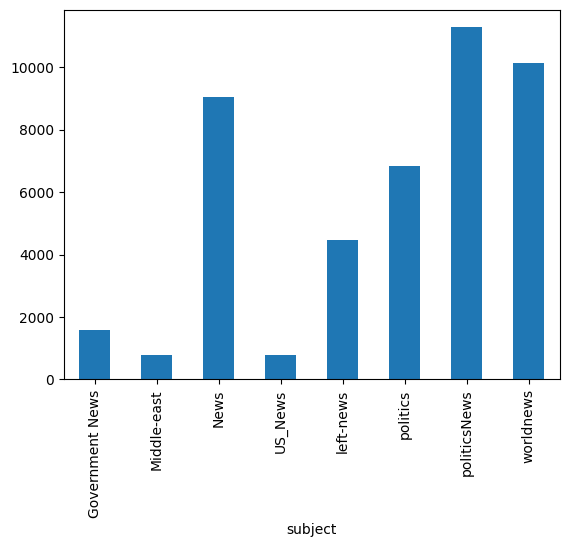

In [16]:
print(data.groupby(['subject'])['text'].count())
data.groupby(['subject'])['text'].count().plot(kind="bar")
plt.show()

target
fake    23481
true    21417
Name: text, dtype: int64


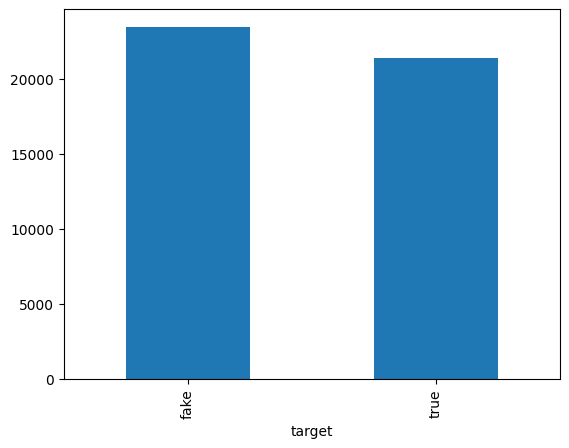

In [17]:
print(data.groupby(['target'])['text'].count())
data.groupby(['target'])['text'].count().plot(kind='bar')
plt.show()

In [27]:
from nltk import tokenize

token_space = tokenize.WhitespaceTokenizer()

def counter(text, column_text, quantity):
    all_words = ' '.join([text for text in text[column_text]])
    token_phrase = token_space.tokenize(all_words)
    frequency = nltk.FreqDist(token_phrase)
    df_frequency = pd.DataFrame({"Word": list(frequency.keys()),
                                 "Frequency": list(frequency.values())})
    df_frequency = df_frequency.nlargest(columns="Frequency", n=quantity)
    plt.figure(figsize=(12,8))
    ax = sns.barplot(data=df_frequency, x="Word", y="Frequency", color='pink')
    ax.set(ylabel="Count")
    plt.xticks(rotation='vertical')
    plt.show()

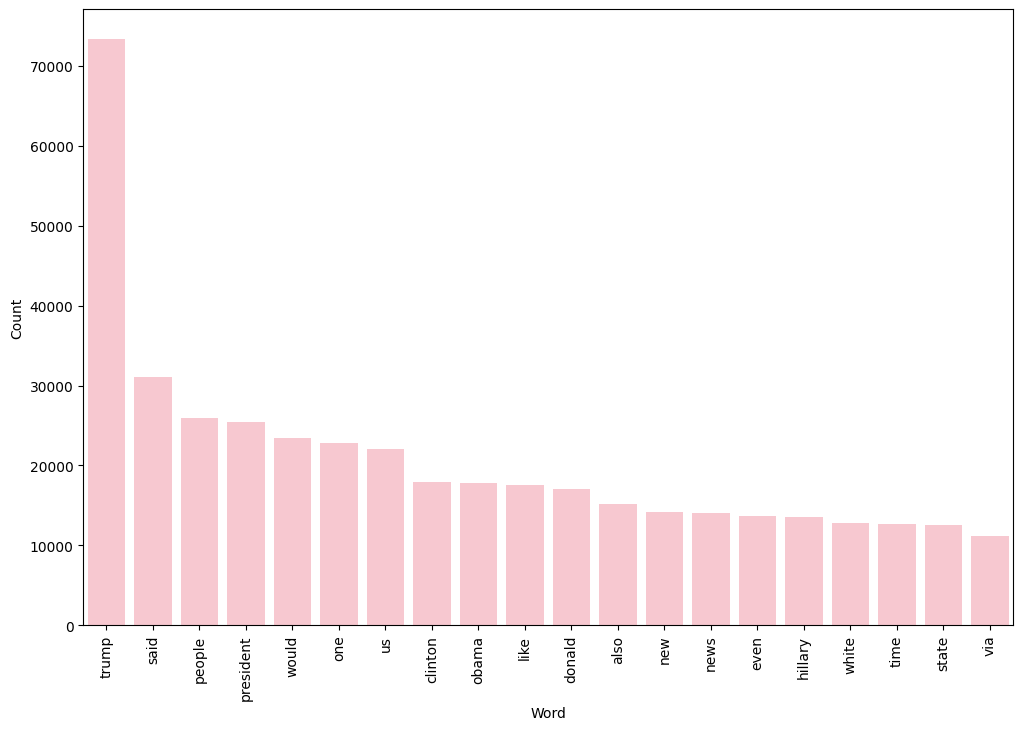

In [29]:
counter(data[data["target"] == "fake"], "text", 20)

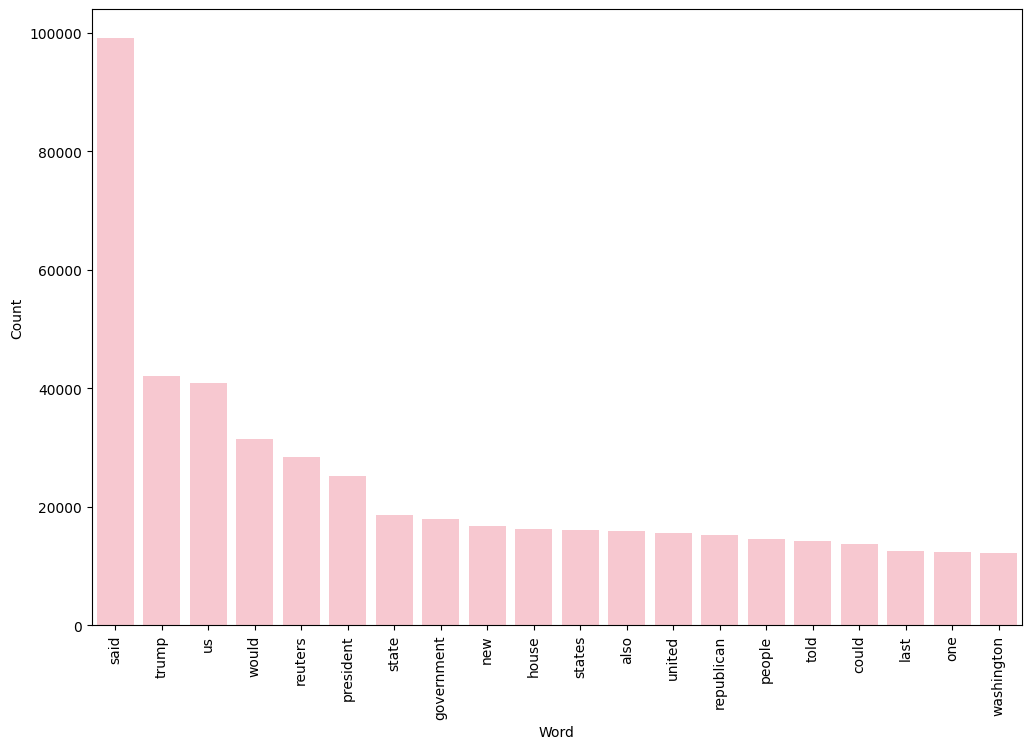

In [20]:
counter(data[data["target"] == "true"], "text", 20)

In [21]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(data['text'], data.target, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

pipe = Pipeline([('vec', CountVectorizer()),
                 ('tfidf', TfidfTransformer()),
                 ('model', LogisticRegression())])

model = pipe.fit(X_train, y_train)
prediction = model.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, prediction)*100,2)))

accuracy: 98.89%


Confusion matrix, without normalization


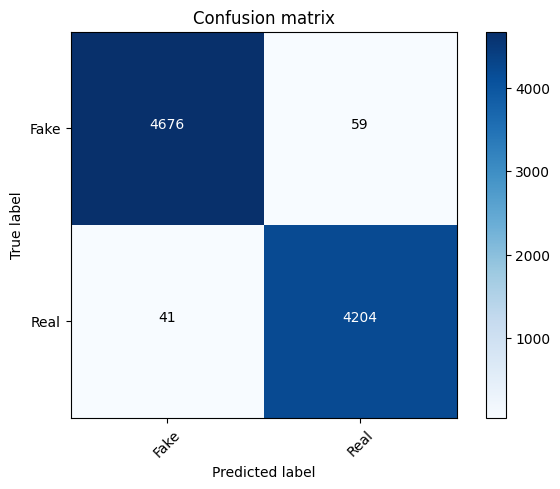

In [24]:
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, prediction)
plot_confusion_matrix(cm, classes=['Fake', 'Real'])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([('vec', CountVectorizer()),
                 ('tfidf', TfidfTransformer()),
                 ('model', RandomForestClassifier(n_estimators=50, criterion="entropy"))])

model = pipe.fit(X_train, y_train)
prediction = model.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, prediction)*100,2)))

Confusion matrix, without normalization


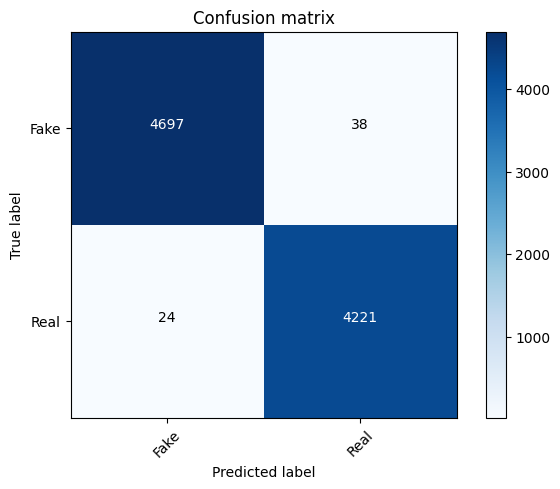

In [26]:
cm = metrics.confusion_matrix(y_test, prediction)
plot_confusion_matrix(cm, classes=['Fake', 'Real'])